In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
df_clean = pd.read_csv("/Users/victoriayuzova/Data-Science-Projects/ba-events-recommender/data/processed/events_clean.csv")
df_clean.head()

,url,title,summary,category,venue,is_free,tags,confidence,homepage_url,liked
0,https://complejoteatral.gob.ar/ver/GERALD-CLAY...,GERALD CLAYTON TRIO,Comienza el ciclo de jazz en el Teatro San Mar...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'Gerald Clayton', 'Trio', 'Teatro San...",0.95,https://complejoteatral.gob.ar/,0
1,https://complejoteatral.gob.ar/ver/la_gaviota,La Gaviota,"Obra de teatro de Antón Chéjov, dirigida por R...",theatre,"Teatro San Martín, Sala Casacuberta",False,"['teatro', 'obra', 'Antón Chéjov', 'Rubén Szuc...",0.95,https://complejoteatral.gob.ar/,1
2,https://complejoteatral.gob.ar/ver/jazz_buenos...,Jazz Buenos Aires,Ciclo de nueve conciertos de Jazz at Lincoln C...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'concierto', 'música', 'Jazz at Linco...",0.95,https://complejoteatral.gob.ar/,1
3,https://complejoteatral.gob.ar/ver/los-pilares...,LOS PILARES DE LA SOCIEDAD,Obra de teatro de Henrik Ibsen que denuncia la...,theatre,"Teatro Presidente Alvear, Av. Corrientes 1659",False,"['Henrik Ibsen', 'teatro', 'obra', 'funciones ...",0.95,https://complejoteatral.gob.ar/,1
4,https://complejoteatral.gob.ar/ver/invasiones-1,INVASIONES I,Invasiones I: No Bombardeen Buenos Aires es un...,theatre,"Teatro San Martín, Sala Martín Coronado",False,"['musical', 'opera rock', 'Elena Roger', 'Char...",0.95,https://complejoteatral.gob.ar/,0


In [4]:

# Combine summary and tags into one text field
df_clean['text'] = df_clean['summary'] + ' ' + df_clean['tags'].apply(lambda x: ' '.join(x))

# Build TF-IDF matrix
tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df_clean['text'])

print(tfidf_matrix.shape)

(36, 100)


In [ ]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:50]) 

['00' '17' '1960' '20' '2026' '30' 'aborda' 'abril' 'actividad' 'aires'
 'al' 'amaral' 'argentina' 'arte' 'artística' 'belleza' 'buenos' 'ciclo'
 'cine' 'como' 'con' 'conferencia' 'contemporáneo' 'cuerpo' 'cultural'
 'curso' 'de' 'del' 'desde' 'donde' 'dos' 'durante' 'el' 'en' 'entre'
 'equipo' 'es' 'escena' 'escritores' 'ese' 'espacio' 'exhibition'
 'experimentación' 'exposición' 'fernanda' 'figura' 'forma' 'funciones'
 'garcía' 'hasta']


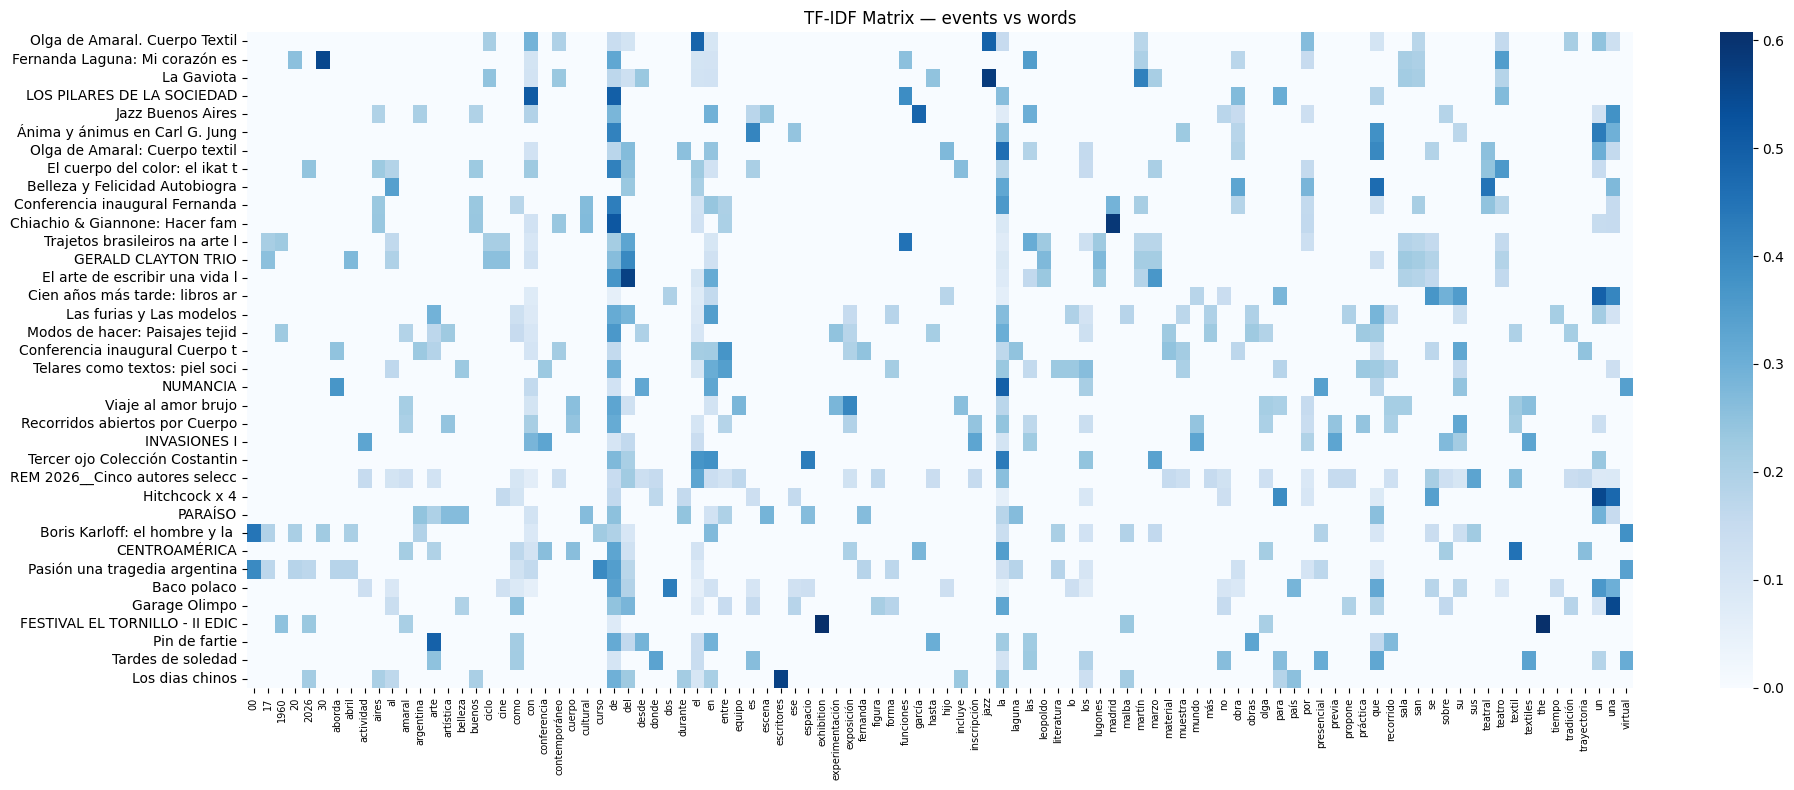

In [16]:
plt.figure(figsize=(20, 8))
sns.heatmap(tfidf_matrix.toarray(),
            yticklabels=df_clean['title'].str[:30],
            xticklabels=feature_names,
            cmap='Blues')
plt.title('TF-IDF Matrix — events vs words')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [5]:
print(tfidf_matrix.shape)
print(df_clean.shape)
print(df_clean['liked'].value_counts())

(36, 100)
(36, 11)
liked
0    26
1    10
Name: count, dtype: int64


In [6]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)

(36, 36)


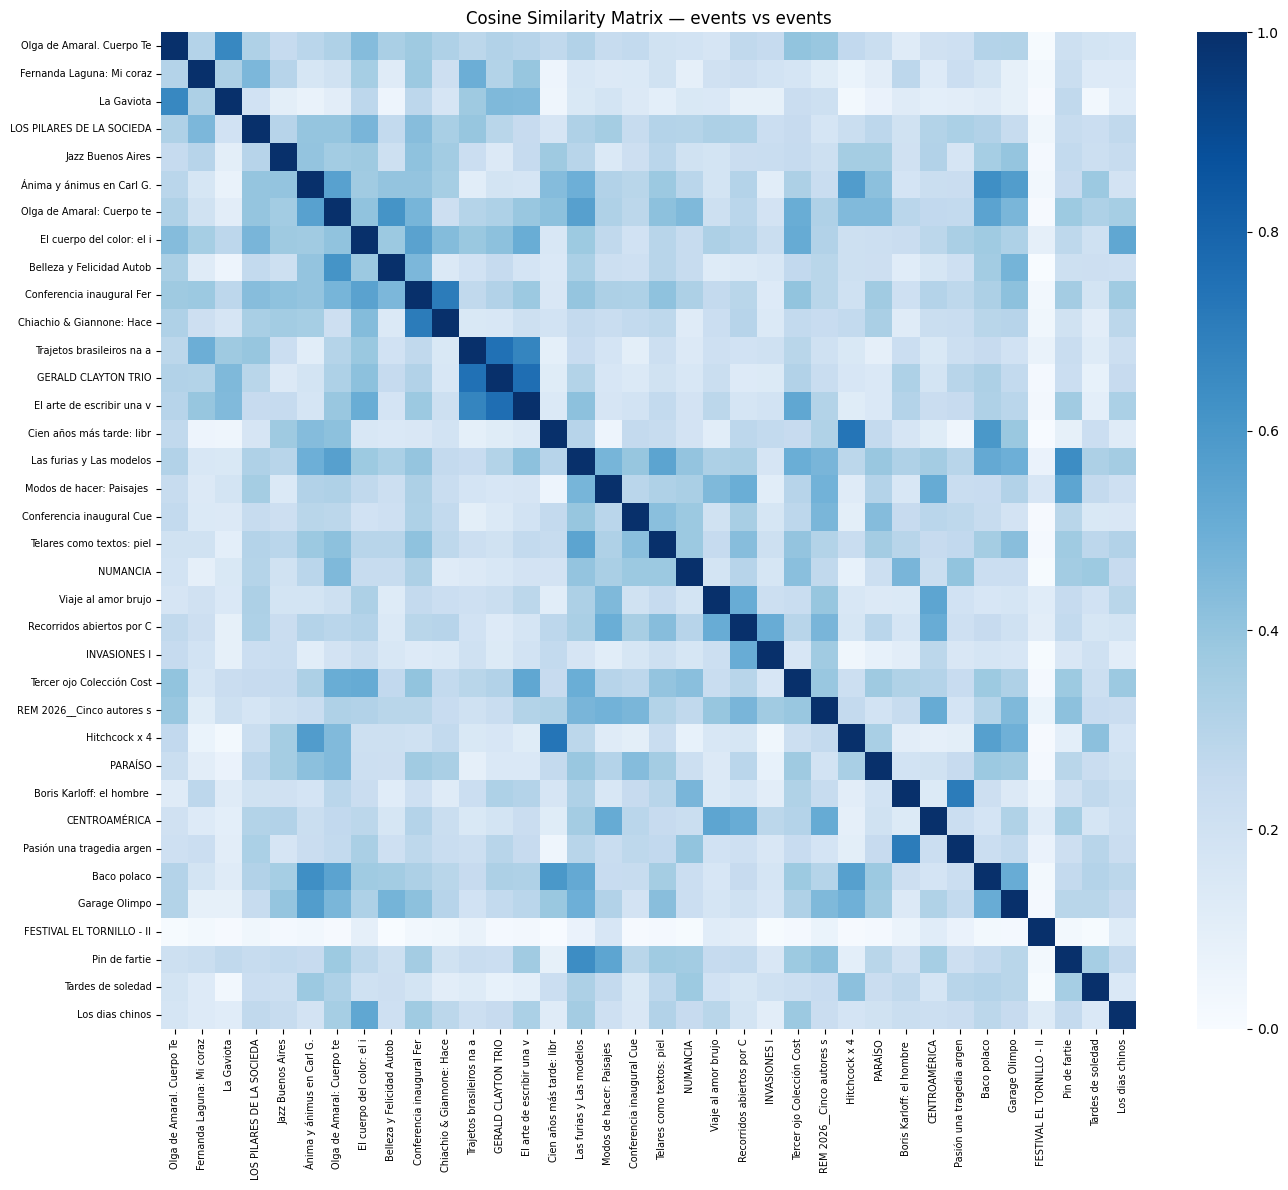

In [17]:
plt.figure(figsize=(14, 12))
sns.heatmap(similarity_matrix,
            xticklabels=df_clean['title'].str[:25],
            yticklabels=df_clean['title'].str[:25],
            cmap='Blues',
            annot=False)
plt.title('Cosine Similarity Matrix — events vs events')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [7]:
liked_indices = df_clean[df_clean['liked']==True].index.tolist()

scores = similarity_matrix[liked_indices].mean(axis=0)

df_clean['rec_score'] = scores

recommendations = (df_clean[df_clean['liked'] == 0]
                   .sort_values('rec_score', ascending=False)
                   [['title', 'category', 'is_free', 'rec_score']]
                   .head(10))

print(recommendations)


                                            title    category is_free  \
21             Chiachio & Giannone: Hacer familia  exhibition    True   
15       Tercer ojo Colección Costantini en Malba  exhibition     NaN   
9                                        NUMANCIA     theatre   False   
6                                     Baco polaco     theatre   False   
33  Trajetos brasileiros na arte latino-americana  exhibition   False   
0                             GERALD CLAYTON TRIO       music   False   
24          Recorridos abiertos por Cuerpo textil  exhibition   False   
7               FESTIVAL EL TORNILLO - II EDICIÓN     theatre     NaN   
23                                  Hitchcock x 4      cinema     NaN   
5                                         PARAÍSO     theatre   False   

    rec_score  
21   0.311179  
15   0.307001  
9    0.301849  
6    0.281833  
33   0.277752  
0    0.267276  
24   0.264512  
7    0.263160  
23   0.260916  
5    0.246884  


In [18]:
print(scores)

[0.26727556 0.26769455 0.22648203 0.33976901 0.21555711 0.24688374
 0.28183343 0.2631603  0.17821308 0.30184931 0.21458142 0.2278104
 0.20152587 0.22554057 0.15337864 0.3070012  0.32074879 0.32337937
 0.33262259 0.30456052 0.22236931 0.31117913 0.22433441 0.26091569
 0.26451194 0.12602377 0.28796079 0.21178325 0.2409931  0.23168821
 0.22634246 0.21208168 0.13157951 0.27775165 0.18984097 0.18659738]


In [19]:
top5 = (df_clean[df_clean['liked'] == 0]
        .sort_values('rec_score', ascending=False)
        .head(5)[['title', 'category', 'is_free', 'rec_score', 'summary', 'url']]
        .reset_index(drop=True))

for i, row in top5.iterrows():
    print(f"#{i+1} {row['title']}")
    print(f"    Category: {row['category']} | Free: {row['is_free']} | Score: {row['rec_score']:.3f}")
    print(f"    {row['summary'][:150]}...")
    print(f"    {row['url']}")
    print()

#1 Chiachio & Giannone: Hacer familia
    Category: exhibition | Free: True | Score: 0.311
    Los artistas Chiachio & Giannone proponen un recorrido por las salas de la exposición Cuerpo textil, estableciendo relaciones y vínculos entre su prod...
    https://malba.org.ar/evento/hacer-familia/

#2 Tercer ojo Colección Costantini en Malba
    Category: exhibition | Free: nan | Score: 0.307
    Una exposición que reúne más de 220 obras icónicas del arte latinoamericano en un recorrido que pone en diálogo la Colección Malba y la de su fundador...
    https://malba.org.ar/evento/tercer-ojo__coleccion-costantini_en-malba/

#3 NUMANCIA
    Category: theatre | Free: False | Score: 0.302
    Obra teatral dirigida por José Luis Alonso de Santos, inspirada en hechos históricos de la ciudad celtíbera de Numancia, que refleja la lucha contra l...
    https://complejoteatral.gob.ar/ver/numancia

#4 Baco polaco
    Category: theatre | Free: False | Score: 0.282
    Obra teatral de Mauricio Kartun q